In [91]:
import sys
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pprint import pprint
from helper_functions import data_reader
from shapely.geometry import Point, MultiPoint, Polygon, MultiPolygon
from shapely.ops import nearest_points

### Load all relevant data


In [92]:
df_CF = data_reader.getCFs() # CFs for all ecoregions
df_ecoregions = data_reader.getEcoregions()
df_miningPolygons = data_reader.getMiningPolygons()
df_miningFacilities = data_reader.getMiningFacilities()
df_miningMinerals = data_reader.getMiningMinerals()
df_miningCommodities = data_reader.getMiningCommodities()
df_miningSourceIDs = data_reader.getSourceIDs()
df_miningMaterialIDs = data_reader.getMaterialIDs()
df_miningReserves = data_reader.getReserves()
df_materialsList = data_reader.getMaterialsList()

In [93]:
# Lookup tables
commodity_lookup = df_materialsList.set_index('material_id')['material_name'].to_dict()

### Show the in reserves contained commodities

In [94]:
uniqueCommodities = df_miningReserves['commodity'].unique()

print("List of commodities in the mining reserves dataset:")
for commodity in uniqueCommodities:
    name = commodity_lookup.get(commodity)
    print(commodity, ': ', name)

List of commodities in the mining reserves dataset:
Me.Ag :  Silver
Me.Au :  Gold
Me.Cu :  Copper
Me.Zn :  Zinc
Me.Fe :  Iron
nan :  None
Nm.S :  None
Me.Mo :  Molybdenum
Me.Al2O3 :  Alumina
Nm.SiO2 :  None
Me.Pb :  Lead
Me.pgm :  PGM
Me.Co :  Cobalt
Me.Ni :  Nickel
Nm.PO :  Phosphate and Phosphorus oxides
Nm.dia :  Diamonds (unspecified)
Me.Mn :  Manganese
Me.Nb :  Niobium
Me.Cr2O3 :  None
Me.U :  None
Nm.P :  None
O.FeTiO3 :  Ilmenite
O.TiO2 :  Rutile
O.Zr :  Zircon
Me.AsCu :  None
Me.Pd :  Palladium
Me.Pt :  Platinum
Me.Li2O :  Lithium oxide
Me.Ca :  None
Me.Mg :  None
Me.Sn :  Tin
Me.KCl :  None
Me.WO3 :  None
Me.Te :  Tellurium


In [95]:
coal = pd.read_csv('data/mining/jasansky/data/coal.csv')
#coal
# TODO: What to do with coal?

### Merge Characterisation factors to the ecoregions

In [96]:
# Unify datatype of ecoregion ids to ensure correct join
df_ecoregions['ECO_ID'] = df_ecoregions['ECO_ID'].astype(int)
df_CF['eco_id'] = df_CF['eco_id'].astype(int)

# Drop unnecessary columns
df_ecoregions = df_ecoregions.drop(
    columns=['OBJECTID', 'AREA', 'PERIMETER', 'REALM', 'BIOME',
    'ECO_NUM', 'ECO_SYM', 'GBL_STAT', 'G200_REGIO', 'G200_NUM',
    'G200_BIOME', 'G200_STAT', 'Shape_Leng', 'Shape_Area', 'area_km2',
    'eco_code', 'PER_area', 'PER_area_1', 'PER_area_2'], axis=1
)
df_CF = df_CF.drop(
    columns=["realm","biome","eco_name","species_group","kingdom"], axis=1
)

# Group CFs by ecoregion into list of dicts
df_CF_grouped = (
    df_CF.groupby("eco_id")
    .apply(lambda g: g.to_dict(orient="records"), include_groups=False)  # list of row-dicts
    .reset_index(name="cf_data")  # put it into a column
)

# Merge CFs with ecoregions
df_CF_ecoregions = df_ecoregions.merge(
    df_CF_grouped, left_on='ECO_ID', right_on='eco_id'
).drop(columns=['eco_id'], axis=1 # drop duplicate eco_id column
).rename(columns={'ECO_NAME': 'eco_name', 'ECO_ID': 'eco_id', 'geometry':'eco_geometry'}) # rename for clarity

# Set geometry to ecoregion geometry
df_CF_ecoregions.set_geometry("eco_geometry", inplace=True)

# Check which ecoregions don't have a match in df_CF
matched_ids = df_CF['eco_id'].unique()
all_ids = df_ecoregions['ECO_ID'].unique()
missing_ids = np.setdiff1d(all_ids, matched_ids)
unmatched_names = df_ecoregions[df_ecoregions['ECO_ID'].isin(missing_ids)]['ECO_NAME'].unique()
print(f"CF has {len(matched_ids)} ecoregions and in total there would be {len(all_ids)}.\n"
    f"The unmatched ecoregions are {missing_ids}, {unmatched_names} which are now absent in the further analysis.")

# Check if crs is EPSG4326, change it otherwise
if df_CF_ecoregions.crs != "EPSG:4326":
    df_CF_ecoregions = df_CF_ecoregions.to_crs("EPSG:4326")
else:
    print("CRS is already EPSG:4326")

CF has 825 ecoregions and in total there would be 827.
The unmatched ecoregions are [-9999 -9998], ['Rock and Ice' 'Lake'] which are now absent in the further analysis.
CRS is already EPSG:4326


### Prepare the mining data

#### Ore grade estimation (Not needed at the moment, but maybe down the line)

In [ ]:
#TODO: Get a proxy for grade_ppm if missing, e.g. average grade_ppm for that commodity in that country or globally 
# and then compute the commodity_value_tonnes from that

# Filter out rows that have no data
df_reserves = df_miningReserves[
    ~(df_miningReserves['mineral_value_tonnes'].isna() & 
      df_miningReserves['commodity_value_tonnes'].isna() | df_miningReserves['commodity'].isna())
].copy()

# Split into already available commodity data and missing ones
df_available_ppm = df_reserves[df_reserves['commodity_value_tonnes'].notna() & df_reserves['grade_ppm'].notna()]
df_missing = df_reserves[df_reserves['commodity_value_tonnes'].isna()]
print(df_available_ppm['commodity'].nunique(), "commodities with available commodity_value_tonnes and grade_ppm")
print(df_reserves['commodity'].nunique(), "commodities in total")
print(len(df_missing), "rows with missing commodity_value_tonnes")

# Compute stats per commodity
df_ppm = df_available_ppm.groupby('commodity')['grade_ppm'].agg(['mean', 'min', 'max', 'count']).reset_index()
df_ppm['commodity_name'] = df_ppm['commodity'].map(commodity_lookup)

# Count the number of rows per commodity
df_noppm = df_missing.groupby('commodity').size().reset_index(name='no_ppm_count')
df_noppm['commodity_name'] = df_noppm['commodity'].map(commodity_lookup)
# put them side by side
df_ppm = df_ppm.merge(df_noppm, on=['commodity', 'commodity_name'], how='outer')

# Compute mean grade per commodity
mean_ppm = df_available_ppm.groupby('commodity')['grade_ppm'].mean()

# Fill missing grade_ppm in df_missing directly
df_missing.loc[:, 'grade_ppm'] = df_missing['grade_ppm'].fillna(df_missing['commodity'].map(mean_ppm))
print(len(df_missing[df_missing['grade_ppm'].notna()]), 'rows now have grade_ppm estimated')
print(len(df_missing[df_missing['grade_ppm'].isna()]), 'rows still have grade_ppm missing and will be dropped')

df_ppm

# Compute number of non-null entries and percentage per column
summary = pd.DataFrame({
    'non_null_count': df_reserves.notnull().sum(),
    'percent': (df_reserves.notnull().mean() * 100)
})

# Reset index to have column names as a column
summary = summary.reset_index().rename(columns={'index': 'column_name'})

# Optionally, sort by percentage descending
summary = summary.sort_values(by='percent', ascending=False)

# Display the table
print(summary)

df_ppm[['commodity', 'commodity_name', 'mean', 'min', 'max', 'count', 'no_ppm_count']]

In [97]:
### 
# Prepare Reserves Data
###

# Group all reserves of one facility to merge later
cols_to_keep = ["year", "material", "mineral_value_tonnes", "commodity", "commodity_value_tonnes"]
df_groupedReserves = (
    df_miningReserves.groupby("facility_id")
    .apply(lambda g: g[cols_to_keep].to_dict(orient="records"), include_groups=False)  # list of row-dicts
    .reset_index(name="res_data")  # put it into a column
)
print(len(df_groupedReserves), "unique facilities with reserve data")

# Safe the facilities with complete commodity_value_tonnes data to a new dataframe
df_commodities_reserves = pd.DataFrame(columns=df_groupedReserves.columns)
for index, row in df_groupedReserves.iterrows():
    # Collect all the values to check for NaN
    values = [item.get('commodity_value_tonnes') for item in row['res_data']]

    # Check that all values are NOT NaN
    if all(
        (v is not None) and (not (math.isnan(v)))
        for v in values
    ):
        # If so, append the row to the new DataFrame
        df_commodities_reserves = pd.concat(
            [df_commodities_reserves, row.to_frame().T], 
            ignore_index=True
        )

print(len(df_commodities_reserves), "facilities with commodity_value_tonnes")
print(len(df_miningReserves[df_miningReserves['commodity_value_tonnes'].isnull()]['facility_id'].unique()), "facilities without commodity_value_tonnes")

# Make sure there are no overlapping facilities
fac_nonnull = set(df_commodities_reserves['facility_id'].unique())
fac_null = set(df_miningReserves[df_miningReserves['commodity_value_tonnes'].isnull()]['facility_id'].unique())
overlap = fac_nonnull.intersection(fac_null)
print(len(overlap), "facilities appear in both (nonnull + null)")
if overlap:
    print("Overlapping facility IDs:", overlap)

668 unique facilities with reserve data
223 facilities with commodity_value_tonnes
445 facilities without commodity_value_tonnes
0 facilities appear in both (nonnull + null)


In [98]:
df_wholeFacilities = df_miningFacilities[df_miningFacilities['facility_id'].str.endswith("00") & ~df_miningFacilities.geometry.is_empty].copy()

# Keep only these that have not stopped production
df_wholeFacilities = df_wholeFacilities[(df_wholeFacilities['production_end'].isnull())].copy()

# Drop unnecessary columns
df_wholeFacilities = df_wholeFacilities.drop(columns=[
    'facility_name', 'facility_other_names', 'sub_site_name', 'sub_site_other_names', 'production_start', 'GID_0', 'GID_1', 'GID_2', 'GID_3', 'GID_4', 'production_start', 'production_end'
])

# Merge reserves with whole facilities, only keep those with geometry
df_facility_reserves = df_wholeFacilities.merge(df_commodities_reserves, on='facility_id', how='inner')

# Check for multipoints
multi_entities = df_facility_reserves[df_facility_reserves.geometry.apply(
    lambda geom: geom.geom_type == "MultiPoint" and len(geom.geoms) > 1
)]

print(len(df_facility_reserves), "whole facilities with reserve data and geometry")
print("12 Mines were lost because they corresponded to mines that had no geometry.")
print(len(multi_entities), "facilities with actual multipoints")
print(df_facility_reserves['surface_area_sq_km'].nunique(), "facilities have a surface area value")
print(df_facility_reserves['concession_area_sq_km'].nunique(), "facilities have a concession area value")

211 whole facilities with reserve data and geometry
12 Mines were lost because they corresponded to mines that had no geometry.
22 facilities with actual multipoints
2 facilities have a surface area value
14 facilities have a concession area value


In [99]:
def joinSinglePoint(single_points, polygons, max_distance=1000):
# Copy to avoid modifying original
    points = single_points.copy()
    polys = polygons.copy()
    
    # Track which polygons have been assigned
    used_polygons = set()
    used_geometries = list()
    # List to collect results
    results = []

    # Compute all distances between points and polygons (optional: limit to max_distance)
    # Using GeoPandas spatial indexing can speed this for large datasets
    for _, point in points.iterrows():
        # Candidates: polygons within max_distance
        polys_within = polys[polys.distance(point.geometry) <= max_distance].copy()
        if polys_within.empty:
            #print(f"No polygons within {max_distance}m for facility {point['facility_id']}")
            combined = {**point.to_dict(), 'ISO3_CODE': None, 'COUNTRY_NAME': None, 'AREA': None, 'polygon_geometry': None, 'distance': None}
            results.append(combined)
            continue

        # Sort candidates by distance
        polys_within['distance'] = polys_within.geometry.distance(point.geometry)
        polys_within = polys_within.sort_values('distance')
        
        # Pick the closest polygon not already assigned
        for poly_idx, poly_row in polys_within.iterrows():
            if poly_idx not in used_polygons:
                # Assign
                used_polygons.add(poly_idx)
                used_geometries.append(poly_row['geometry'])
                poly_row = poly_row.rename({'geometry':'polygon_geometry'})
                
                # Combine point + polygon info
                combined = {**point.to_dict(), **poly_row.to_dict()}
                results.append(combined)

                break  # Move to next point
    
    # Convert results to DataFrame
    if results:
        df_result = pd.DataFrame(results)
    else:
        #print(f"No results")
        return 
    
    matched_ids = set(df_result['facility_id'])
    unmatched1 = points[~points['facility_id'].isin(matched_ids)]
    #print(len(unmatched1), "unmatched points")

    # Unmatched points that have a surface area value
    unmatched2 = unmatched1[unmatched1["surface_area_sq_km"].notnull()]
    #print(len(unmatched2), "unmatched points with surface area")

    # Points that are still unmatched (no polygon and no surface area)
    still_unmatched = unmatched1[~unmatched1['facility_id'].isin(unmatched2['facility_id'])]
    #print(len(still_unmatched), "still unmatched points")

    # Save for manual review
    #still_unmatched.to_file("data/manual/unmatched_single_points.geojson", driver="GeoJSON")

    # Add the unmatched-with-surface-area points back into the results
    df_result = pd.concat([df_result, unmatched2], ignore_index=True)

    df_result = gpd.GeoDataFrame(df_result, geometry='geometry', crs=points.crs)

    # Back to WGS84
    df_result = df_result.to_crs("EPSG:4326")
    
    return df_result, used_geometries 

#TODO: If wanted, minimize for total distance between points and polygons

In [100]:
def joinMultiPoints(multi_points, polygons, all_facilities, max_distance=1000):
    """
    Join multipoint facilities (with submines) to polygons.
    If multiple submines exist: match all submines individually, sum their polygon areas,
    and keep only the geometry of the first submine as representative.
    If only one submine: treat like a single-point facility.
    """

    multis = multi_points.copy()
    polys = polygons.copy()
    all_facs = all_facilities.copy()

    results = []
    all_used_geoms = []

    for _, facility_row in multis.iterrows():
        prefix = facility_row["facility_id"][:9]
        subs = all_facs[
            (all_facs["facility_id"].str.startswith(prefix)) &
            (~all_facs["facility_id"].str.endswith("00"))
        ].copy()

        # No submines
        if subs.empty:
            #print(f"No sub-mines for multipoint facility {facility_row['facility_id']}")
            continue

        # One submine
        elif len(subs) == 1:
            sub = subs.iloc[[0]]
            joined_sub, used_geoms = joinSinglePoint(sub, polys, max_distance=max_distance)
            polys = polys[~polys.geometry.isin(used_geoms)].copy()

            if len(joined_sub) > 0:
                results.append(joined_sub.iloc[0].to_dict())
                all_used_geoms.extend(used_geoms)

        # Multiple submines
        else:
            joined_subs, used_geoms = joinSinglePoint(subs, polys, max_distance=max_distance)
            polys = polys[~polys.geometry.isin(used_geoms)].copy()
            all_used_geoms.extend(used_geoms)
            
            if len(joined_subs) == 0:
                #print(f"No unused polygons found for submines of {facility_row['facility_id']}")
                continue


            # Convert AREA to numeric
            joined_subs["AREA"] = pd.to_numeric(joined_subs["AREA"], errors='coerce')

            # Pick representative submine
            valid_subs = joined_subs[joined_subs['AREA'].notna() | joined_subs['surface_area_sq_km'].notna()]
            if not valid_subs.empty:
                rep_submine = valid_subs.iloc[0].copy()
            else:
                rep_submine = joined_subs.iloc[-1].copy()

            # Sum polygon areas of all matched submines (use all matched polygons, not just valid_subs)
            total_polygon_area = joined_subs["AREA"].sum(skipna=True)

            # Combine parent facility info with polygon attributes
            combined = {
                **facility_row.to_dict(),  # facility-level info
                **rep_submine[['ISO3_CODE', 'COUNTRY_NAME', 'polygon_geometry', 'distance']].to_dict()  # keep polygon info
            }

            # Overwrite key fields
            combined["AREA"] = total_polygon_area       # summed polygon area
            combined["geometry"] = rep_submine["geometry"]  # first submine's point

            # Append to results
            results.append(combined)
            
    # Convert results to GeoDataFrame
    if results:
        df_result = gpd.GeoDataFrame(results, geometry="geometry", crs=multi_points.crs)
    else:
        #print("No multipoint facilities matched any polygons.")
        df_result = gpd.GeoDataFrame(columns=list(multi_points.columns) + ['ISO3_CODE', 'COUNTRY_NAME', 'AREA', 'polygon_geometry', 'distance'], crs=multi_points.crs)

    # Change crs back to WGS84
    df_result = df_result.to_crs("EPSG:4326")

    return df_result


In [101]:
assert df_miningPolygons.crs == df_facility_reserves.crs, "CRS of mining polygons and facilities do not match"

# Convert to projected CRS for distance calculations (Web Mercator (meters))
df_facility_reserves = df_facility_reserves.to_crs(3857)
df_miningPolygons = df_miningPolygons.to_crs(3857)
df_miningFacilities = df_miningFacilities.to_crs(3857)

# Split facilities in single points and multiple points when all geometries are multipoints
df_singlePoints = df_facility_reserves[
    df_facility_reserves.geometry.apply(
        lambda g: isinstance(g, MultiPoint) and len(g.geoms) == 1
    )
].copy()
df_singlePoints['geometry'] = df_singlePoints['geometry'].apply(lambda g: list(g.geoms)[0])  # extract the single Point
print(len(df_singlePoints), "single point facilities")

df_multiPoints = df_facility_reserves[
    df_facility_reserves.geometry.apply(
        lambda g: isinstance(g, MultiPoint) and len(g.geoms) > 1
    )
].copy()
print(len(df_multiPoints), "multiple point facilities")

# Join single points with polygons
df_singlePoint_facilities_polygons, used_geometries = joinSinglePoint(df_singlePoints, df_miningPolygons)

# Keep only rows where at least one of AREA or surface_area_sq_km is not null
df_singlePoint_facilities_polygons = df_singlePoint_facilities_polygons[
    (df_singlePoint_facilities_polygons['AREA'].notna() & (df_singlePoint_facilities_polygons['AREA'] != 0)) |
    df_singlePoint_facilities_polygons['surface_area_sq_km'].notna()
].copy()

print(f"{len(df_singlePoint_facilities_polygons)} single point facilities matched with polygons")

# Remove used polygons from the pool for multipoint matching
print(len(used_geometries), "polygons used for single point facilities")
print(len(df_miningPolygons), "polygons before removing used ones")
df_remainingPolygons = df_miningPolygons[~df_miningPolygons.geometry.isin(used_geometries)].copy()
print(len(df_remainingPolygons), "polygons left for multipoint facilities")

# Join multipoints with remaining polygons
df_multiPoint_facilities_polygons = joinMultiPoints(df_multiPoints, df_remainingPolygons, df_miningFacilities)

# Keep only rows where at least one of AREA or surface_area_sq_km is not null
df_multiPoint_facilities_polygons = df_multiPoint_facilities_polygons[
    (df_multiPoint_facilities_polygons['AREA'].notna() & (df_multiPoint_facilities_polygons['AREA'] != 0)) |
    df_multiPoint_facilities_polygons['surface_area_sq_km'].notna()
].copy()

# Add single and multi point results to one dataframe
df_all_facilities_polygons = pd.concat(
    [df_singlePoint_facilities_polygons, df_multiPoint_facilities_polygons],
    ignore_index=True
)
print(len(df_all_facilities_polygons), "usable mines")

df_miningFacilities = df_miningFacilities.to_crs("EPSG:4326")

189 single point facilities
22 multiple point facilities
177 single point facilities matched with polygons
177 polygons used for single point facilities
44929 polygons before removing used ones
44752 polygons left for multipoint facilities
198 usable mines


### Join the facilities and the characterisation factors

In [102]:
df_facilities_ecoregions = gpd.sjoin(df_all_facilities_polygons, df_CF_ecoregions, how="left", predicate='within', lsuffix="mining", rsuffix="CF_eco")

# Keep only the ones that are mines
df_mines_ecoregions = df_facilities_ecoregions[df_facilities_ecoregions['facility_type'].str.contains("Mine")].copy()

print(len(df_mines_ecoregions), "mines with polygons and ecoregions after spatial join")
print(df_mines_ecoregions['commodities_products'].nunique(), "unique commodities matched to mines")

198 mines with polygons and ecoregions after spatial join
40 unique commodities matched to mines


### Create a new DataFrame with one row per commodity from df_mines_ecoregions

In [104]:
# TODO: Check what materials we actually have in the dataset, like copper, copper sulfate or like that
# TODO: search for actual prices in ecoinvent
def computeTotalPrice(price, res_data):
    """
    Compute total price of all commodities for a given mine
    """
    totalPrice = 0
    for entry in res_data:
        commodity_value_tonnes = entry.get('commodity_value_tonnes')
        totalPrice += commodity_value_tonnes * 1e3 * price  # convert from tonnes to kg and multiply by price
    
    return totalPrice

records = []
for _, row in df_mines_ecoregions.iterrows():
    res_data = row['res_data']
    price = 10  # Placeholder, replace with actual price data if available
    total_commodity_kg = sum(entry.get('commodity_value_tonnes') * 1e3 for entry in res_data)
    total_mine_price = computeTotalPrice(price, res_data)

    facility_id = row['facility_id']
    location = row['geometry']
    #TODO: Check the different area columns on the units
    if row['AREA'] is not None and not (math.isnan(row['AREA'])):
        area = row['AREA']
    elif row['surface_area_sq_km'] is not None and not (math.isnan(row['surface_area_sq_km'])):
        area = row['surface_area_sq_km']
    elif row['concession_area_sq_km'] is not None and not (math.isnan(row['concession_area_sq_km'])):
        area = row['concession_area_sq_km']
    else:
        print(f"Facility {facility_id} has no area information.")
        area = None
    ecoregion = row['eco_id']
    country = row['country']

    for entry in res_data:
        commodity = commodity_lookup.get(entry.get('commodity'))
        commodity_value_tonnes = entry.get('commodity_value_tonnes') * 1e3  # convert from tonnes to kg
        factor = (area * price) / total_mine_price
        records.append({
            'Facility_ID': facility_id,
            'Location [POINT]': location,
            'Area [SQ_KM?]': area,
            'Ecoregion_ID': ecoregion,
            'Country': country,
            'Commodity [kg]': commodity_value_tonnes,
            'Commodity_Name': commodity,
            'Commodity_ID': entry.get('commodity'),
            'Factor [m2/kg]': factor,
            'Price [USD/KG]': price
        })

df_commodities_flat = pd.DataFrame(records)
df_commodities_flat

,Facility_ID,Location [POINT],Area [SQ_KM?],Ecoregion_ID,Country,Commodity [kg],Commodity_Name,Commodity_ID,Factor [m2/kg],Price [USD/KG]
0,COM00016.00,POINT (-1.0231408999999998 6.3456449),11.203951,30111.0,Ghana,7.314177e+04,Gold,Me.Au,1.531813e-04,10
1,COM00033.00,POINT (27.3498955 -24.784390800000004),0.293471,30717.0,South Africa,4.280778e+05,PGM,Me.pgm,6.855555e-07,10
2,COM00035.00,POINT (48.31224496291279 -18.8265594469625),7.582316,30117.0,Madagascar,9.960000e+07,Cobalt,Me.Co,6.341850e-09,10
3,COM00035.00,POINT (48.31224496291279 -18.8265594469625),7.582316,30117.0,Madagascar,1.096000e+09,Nickel,Me.Ni,6.341850e-09,10
4,COM00041.00,POINT (-70.25489939689129 -33.092020302600304),1.997347,61008.0,Chile,8.000000e+09,Copper,Me.Cu,2.496684e-10,10
...,...,...,...,...,...,...,...,...,...,...
311,COM01053.00,POINT (-0.0005973572573469 -0.0002038671946195),5.016225,NaN,Argentina,1.179340e+08,Lead,Me.Pb,2.979973e-08,10
312,COM01053.00,POINT (-0.0005973572573469 -0.0002038671946195),5.016225,NaN,Argentina,4.898798e+07,Zinc,Me.Zn,2.979973e-08,10
313,COM01105.00,POINT (0.00024549427366 -0.0002306099429516),10.675597,NaN,South Africa,2.146626e+06,PGM,Me.pgm,4.973199e-06,10
314,COM01308.00,POINT (-0.0010525386620532 0.0003702851935989),54.796739,NaN,United States of America,3.212001e+05,Gold,Me.Au,1.706000e-04,10


### Show mines

55 Mines with copper, cobalt, or lithium


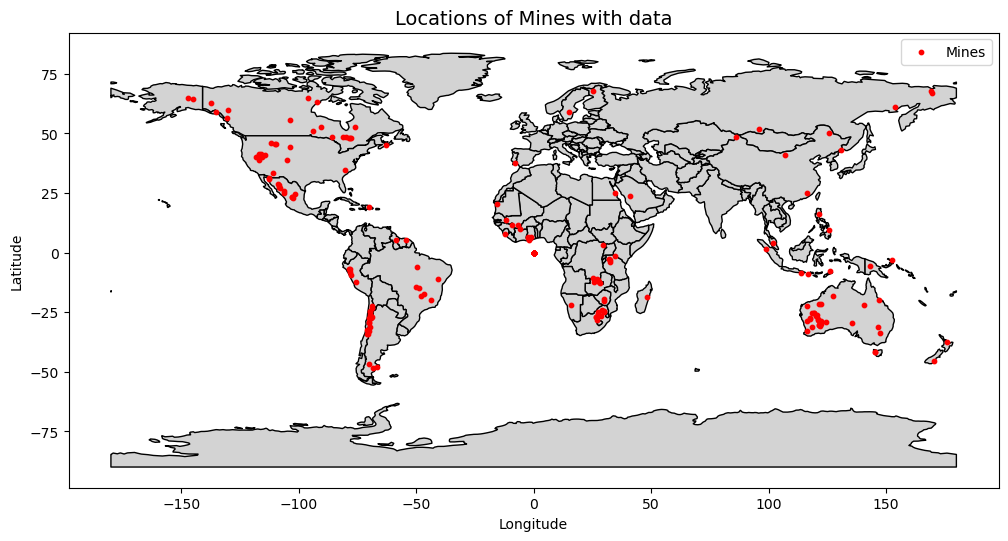

In [27]:
df_copper_cobalt_lithium = df_mines_ecoregions[df_mines_ecoregions['commodities_products'].str.lower().str.contains("copper|cobalt|lithium")].copy()
print(len(df_copper_cobalt_lithium), "Mines with copper, cobalt, or lithium")

fig, ax = plt.subplots(figsize=(12, 8))

# Plot the world basemap
world_path = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_path)
world.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the mines
df_mines_ecoregions.plot(ax=ax, color='red', markersize=10, label="Mines")

# Add plot title and legend
plt.title("Locations of Mines with data", fontsize=14)
plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Test